# Stage 6: Feature Selection & Redundancy Filtering
**Member:** **M6 — IT25100285**
**Assigned Preprocessing Technique:** Mutual-information ranking + correlation (multicollinearity) filter; dataset handover
**Dataset:** [US Permanent Visa Applications](https://www.kaggle.com/datasets/jboysen/us-perm-visas) (US Department of Labor, via Kaggle)
**Group:** 2026-Y02-S1-MLB-B9G1-08
**Pipeline Position:** Stage 6 of 6 (sequential)
**Input:** `results/outputs/stage5_scaled.parquet` and `results/outputs/stage4_features_created.parquet`
**Output:** `results/outputs/final_processed.csv.gz` (handover B) and `results/outputs/cleaned_unscaled_allfeatures.csv.gz` (handover A)

---
## 1. Explanation of the Technique

Feature selection keeps the most informative, non-redundant inputs:
1. **Filter methods** rank features by a statistic computed against the target (correlation, chi-square, **mutual information**) - fast and model-agnostic.
2. **Wrapper methods** (e.g. recursive feature elimination) repeatedly train a model - expensive on 284k rows.
3. **Embedded methods** (L1 penalty, tree importance) select while training - model-specific.
4. **Dimensionality reduction (PCA)** builds new synthetic components - loses interpretability.

**Mutual information (MI)** measures how much knowing a feature reduces uncertainty about the target. Unlike Pearson correlation it captures **non-linear** relationships and works for binary / one-hot features. A **correlation filter** then removes features that duplicate an already-kept one (|r| > 0.85), reducing multicollinearity for linear models.

---
## 2. Justification for THIS Dataset Specifically

- After Stages 2-4 there are **107 candidate features** (many sparse one-hot columns) for 284k training rows - many carry almost no information about denial.
- Several pairs are near-duplicates by construction: offered vs prevailing wage, `wage_gap_annual` vs `wage_to_pw_ratio`, worker vs required education, founding year vs `employer_age`.
- **Why MI and not Pearson** (the teammate template's method): key relationships are non-linear - the denial rate jumps from ~7% to ~65% exactly at `wage_to_pw_ratio = 1` (Stage 4 plot), which a linear correlation underestimates.
- **Leakage-safe:** MI and correlations are computed on **training rows only** (MI on a stratified 60k-row subsample for speed), and the EDA-only columns (`decision_date`, `case_status`) are removed and asserted absent here.
- **Choosing k:** keep features in MI order until 90% of the total MI is covered, bounded to 15-30 features.

### Why this must be Stage 6
- It is the last step before modelling: it needs every engineered feature (Stage 4) on a common scale (Stage 5).
- It produces the **final processed dataset** for the six models, plus one optional variant:
  - **B - `final_processed.csv.gz` (DEFAULT):** the selected features, scaled. Every member trains on B, so the six models are compared on identical data.
  - **A - `cleaned_unscaled_allfeatures.csv.gz` (OPTIONAL):** all 107 features, unscaled - for members who want a "different pre-processing" variety (e.g. all features vs selected, or their own scaling inside CV).

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

# --- Project paths: search upward for the folder that contains data/raw ---
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, 'data', 'raw')) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)

RAW_CSV = os.path.join(ROOT, 'data', 'raw', 'us_perm_visas.csv')
EXT_DIR = os.path.join(ROOT, 'data', 'external')
OUT_DIR = os.path.join(ROOT, 'results', 'outputs')
PLOT_DIR = os.path.join(ROOT, 'results', 'eda_visualizations')
LOG_DIR = os.path.join(ROOT, 'results', 'logs')
for _d in (OUT_DIR, PLOT_DIR, LOG_DIR):
    os.makedirs(_d, exist_ok=True)

# --- Shared settings (identical in every notebook) ---
TARGET = 'denied'            # 1 = Denied, 0 = Certified / Certified-Expired
SEED = 42
TEST_SIZE = 0.20             # stratified 80/20 split; teammates use 5-fold CV on the train rows
DEV_SAMPLE = None            # e.g. 0.10 for a fast ~35k-row run; None = full dataset
EDA_ONLY_COLS = ['case_status', 'decision_date']                          # kept for EDA, dropped in S6
LEAKAGE_COLS = ['case_id', 'case_received_date', 'application_type', 'processing_days']  # must never reach a model
NON_FEATURE_COLS = EDA_ONLY_COLS + [TARGET, 'split']

REFERENCE_YEAR = 2016                                                     # last year in the dataset
S4_PASSTHROUGH = ['employer_state', 'job_info_work_state', 'agent_firm_name']  # raw columns kept by S2 for S4
SCALE_COLS = ['wage_offer_annual', 'pw_annual', 'wage_gap_annual', 'wage_to_pw_ratio',  # continuous / ordinal
              'employer_num_employees_log', 'employer_filing_count_log', 'employer_yr_estab', 'employer_age',
              'pw_level', 'edu_worker', 'edu_required', 'edu_gap']

# --- Reference tables (data/external) ---
_states = pd.read_csv(os.path.join(EXT_DIR, 'us_states.csv'))
STATE_LOOKUP = {**dict(zip(_states['state_name'], _states['state_code'])),
                **dict(zip(_states['state_code'], _states['state_code']))}
STATE_REGION = dict(zip(_states['state_code'], _states['census_region']))
VALID_SOC = set(pd.read_csv(os.path.join(EXT_DIR, 'soc_major_groups.csv'), dtype=str)['soc_major_group'])
_naics = pd.read_csv(os.path.join(EXT_DIR, 'naics_sectors.csv'), dtype=str)
VALID_NAICS = set(_naics['naics_2digit'])
NAICS_SECTOR_KEY = dict(zip(_naics['naics_2digit'], _naics['sector_key']))

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
print(f'Project root: {ROOT}')

Project root: /Users/jathushansundararasu/Desktop/us_prem_visa


In [2]:
# ==============================================================================
# STAGE 6: Feature Selection (IT25100285)
# ==============================================================================
CORR_THRESHOLD = 0.85        # |r| above this = redundant pair
MI_SAMPLE = 60_000           # stratified train subsample for the mutual-information estimate
MI_CUMULATIVE = 0.90         # keep features until 90% of total MI is covered ...
K_BOUNDS = (15, 30)          # ... but at least 15 and at most 30 features

FEATURE_DESCRIPTIONS = {
    'wage_offer_annual': 'Offered wage, annualised USD (winsorised)',
    'pw_annual': 'Prevailing wage, annualised USD (winsorised)',
    'wage_gap_annual': 'Offered minus prevailing wage, USD/yr',
    'wage_to_pw_ratio': 'Offered / prevailing wage, clipped to [0, 5]',
    'wage_below_pw': '1 if offered wage < prevailing wage',
    'employer_num_employees_log': 'log1p(employer employees), winsorised',
    'employer_filing_count_log': 'log1p(other train filings by the same employer), winsorised',
    'employer_yr_estab': 'Employer founding year (winsorised, median-imputed)',
    'employer_age': '2016 - employer founding year',
    'pw_level': 'Prevailing-wage level I-IV = 1-4, Unknown = 0',
    'edu_worker': 'Worker education, High School=1 ... Doctorate=5, Other/Unknown=0',
    'edu_required': 'Required education, High School=1 ... Doctorate=5, Other/Unknown=0',
    'edu_gap': 'edu_worker - edu_required (0 if either unknown)',
    'edu_meets_requirement': '1 if worker education >= required education (both known)',
    'experience_required': '1 if the job requires experience',
    'has_agent': '1 if filed through an attorney / agent firm',
    'same_state': '1 if worksite state = employer state',
    'denied': 'TARGET: 1 = Denied, 0 = Certified / Certified-Expired',
    'split': 'train / test (stratified 80/20, seed 42)',
}
PREFIX_DESCRIPTIONS = {
    'soc_': 'One-hot SOC occupation major group (2-digit code)', 'naics_': 'One-hot NAICS industry sector',
    'region_': 'One-hot employer census region', 'pwsrc_': 'One-hot prevailing-wage source',
    'country_': 'One-hot citizenship (top 20 + Other)', 'coa_': 'One-hot class of admission (top 10 + Other)',
}


def _describe(col):
    if col in FEATURE_DESCRIPTIONS:
        return FEATURE_DESCRIPTIONS[col]
    return next((desc for p, desc in PREFIX_DESCRIPTIONS.items() if col.startswith(p)), '')


def stage6_feature_selection(df_scaled, df_unscaled, plot_dir=PLOT_DIR, out_dir=OUT_DIR, show_plot=False):
    """
    1. Drop EDA-only columns (case_status, decision_date) and assert no leakage column survived.
    2. Rank every feature by mutual information with `denied` (train subsample).
    3. Greedy correlation filter: walk features by MI, drop any with |r| > 0.85 to an already-kept feature.
    4. Keep the top-k remaining features (90% cumulative MI, bounded 15-30).
    Writes handover A (all features, unscaled) and handover B (selected features, scaled).
    Returns (handover_A, handover_B, selection_report).
    """
    a = df_unscaled.drop(columns=EDA_ONLY_COLS)
    s = df_scaled.drop(columns=EDA_ONLY_COLS)
    leaked = [c for c in LEAKAGE_COLS + EDA_ONLY_COLS if c in a.columns or c in s.columns]
    assert not leaked, f'Leakage columns present: {leaked}'
    assert list(a.columns) == list(s.columns) and len(a) == len(s)

    features = [c for c in s.columns if c not in (TARGET, 'split')]
    train = s['split'].eq('train')
    X, y = s.loc[train, features], s.loc[train, TARGET]
    if len(X) > MI_SAMPLE:
        X_mi, _, y_mi, _ = train_test_split(X, y, train_size=MI_SAMPLE, stratify=y, random_state=SEED)
    else:
        X_mi, y_mi = X, y
    discrete = np.array([c not in SCALE_COLS for c in features])
    mi = pd.Series(mutual_info_classif(X_mi, y_mi, discrete_features=discrete, random_state=SEED), index=features)
    mi = mi.sort_values(ascending=False)

    corr = X.corr().abs()
    kept, dropped_for = [], {}
    for col in mi.index:
        partner = next((k for k in kept if corr.loc[col, k] > CORR_THRESHOLD), None)
        if partner is None:
            kept.append(col)
        else:
            dropped_for[col] = partner
    candidates = mi[kept][mi[kept] > 0]
    cumulative = candidates.cumsum() / candidates.sum()
    k = int(np.clip((cumulative < MI_CUMULATIVE).sum() + 1, *K_BOUNDS))
    selected = candidates.index[:k].tolist()

    report = pd.DataFrame({'feature': mi.index, 'mutual_information': mi.values})
    report['rank'] = np.arange(1, len(report) + 1)
    report['dropped_redundant_with'] = report['feature'].map(dropped_for)
    report['selected'] = report['feature'].isin(selected)

    handover_a = a[features + [TARGET, 'split']]
    handover_b = s[selected + [TARGET, 'split']]

    if out_dir:
        handover_a.to_csv(os.path.join(out_dir, 'cleaned_unscaled_allfeatures.csv.gz'), index=False, float_format='%.6g')
        handover_b.to_csv(os.path.join(out_dir, 'final_processed.csv.gz'), index=False, float_format='%.6g')
        report.to_csv(os.path.join(out_dir, 'feature_selection_report.csv'), index=False)
        with open(os.path.join(out_dir, 'selected_features.txt'), 'w') as f:
            f.write('\n'.join(selected) + '\n')
        dictionary = pd.DataFrame({'column': handover_a.columns})
        dictionary['description'] = dictionary['column'].map(_describe)
        dictionary['dtype'] = [str(handover_a[c].dtype) for c in handover_a.columns]
        dictionary['scaled_in_B'] = dictionary['column'].isin(SCALE_COLS)
        dictionary['in_handover_B'] = dictionary['column'].isin(handover_b.columns)
        dictionary.to_csv(os.path.join(out_dir, 'feature_dictionary.csv'), index=False)

    if plot_dir:
        fig, axes = plt.subplots(1, 2, figsize=(20, 9), gridspec_kw={'width_ratios': [1, 1.1]})
        plt.subplots_adjust(wspace=0.35)
        top = report.head(35).iloc[::-1]
        colors = ['#27ae60' if r.selected else ('#e74c3c' if isinstance(r.dropped_redundant_with, str) else '#bdc3c7')
                  for r in top.itertuples()]
        axes[0].barh(top['feature'], top['mutual_information'], color=colors, edgecolor='black', linewidth=0.4)
        axes[0].set_title(f'Mutual information with `denied` (top 35 of {len(report)})\n'
                          f'green = selected ({k}), red = redundant (|r| > {CORR_THRESHOLD}), grey = below cut-off',
                          fontweight='bold')
        axes[0].set_xlabel('Mutual information (nats, train subsample)')
        axes[0].tick_params(axis='y', labelsize=8)
        sel_corr = X[selected].corr()
        im = axes[1].imshow(sel_corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
        axes[1].set_xticks(range(k), selected, rotation=90, fontsize=7)
        axes[1].set_yticks(range(k), selected, fontsize=7)
        axes[1].set_title(f'Correlation between the {k} selected features (max |r| <= {CORR_THRESHOLD})', fontweight='bold')
        fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
        plt.suptitle('m6: Feature selection - mutual information ranking + redundancy filter', fontsize=14, fontweight='bold', y=1.03)
        plt.savefig(f'{plot_dir}/m6_feature_selection.png', dpi=200, bbox_inches='tight')
        plt.show() if show_plot else plt.close()
    print(f'[Stage 6] {len(features)} candidate features -> {len(dropped_for)} redundant dropped -> {k} selected')
    return handover_a, handover_b, report

Loaded Stage 5 data: 354,849 rows x 111 columns


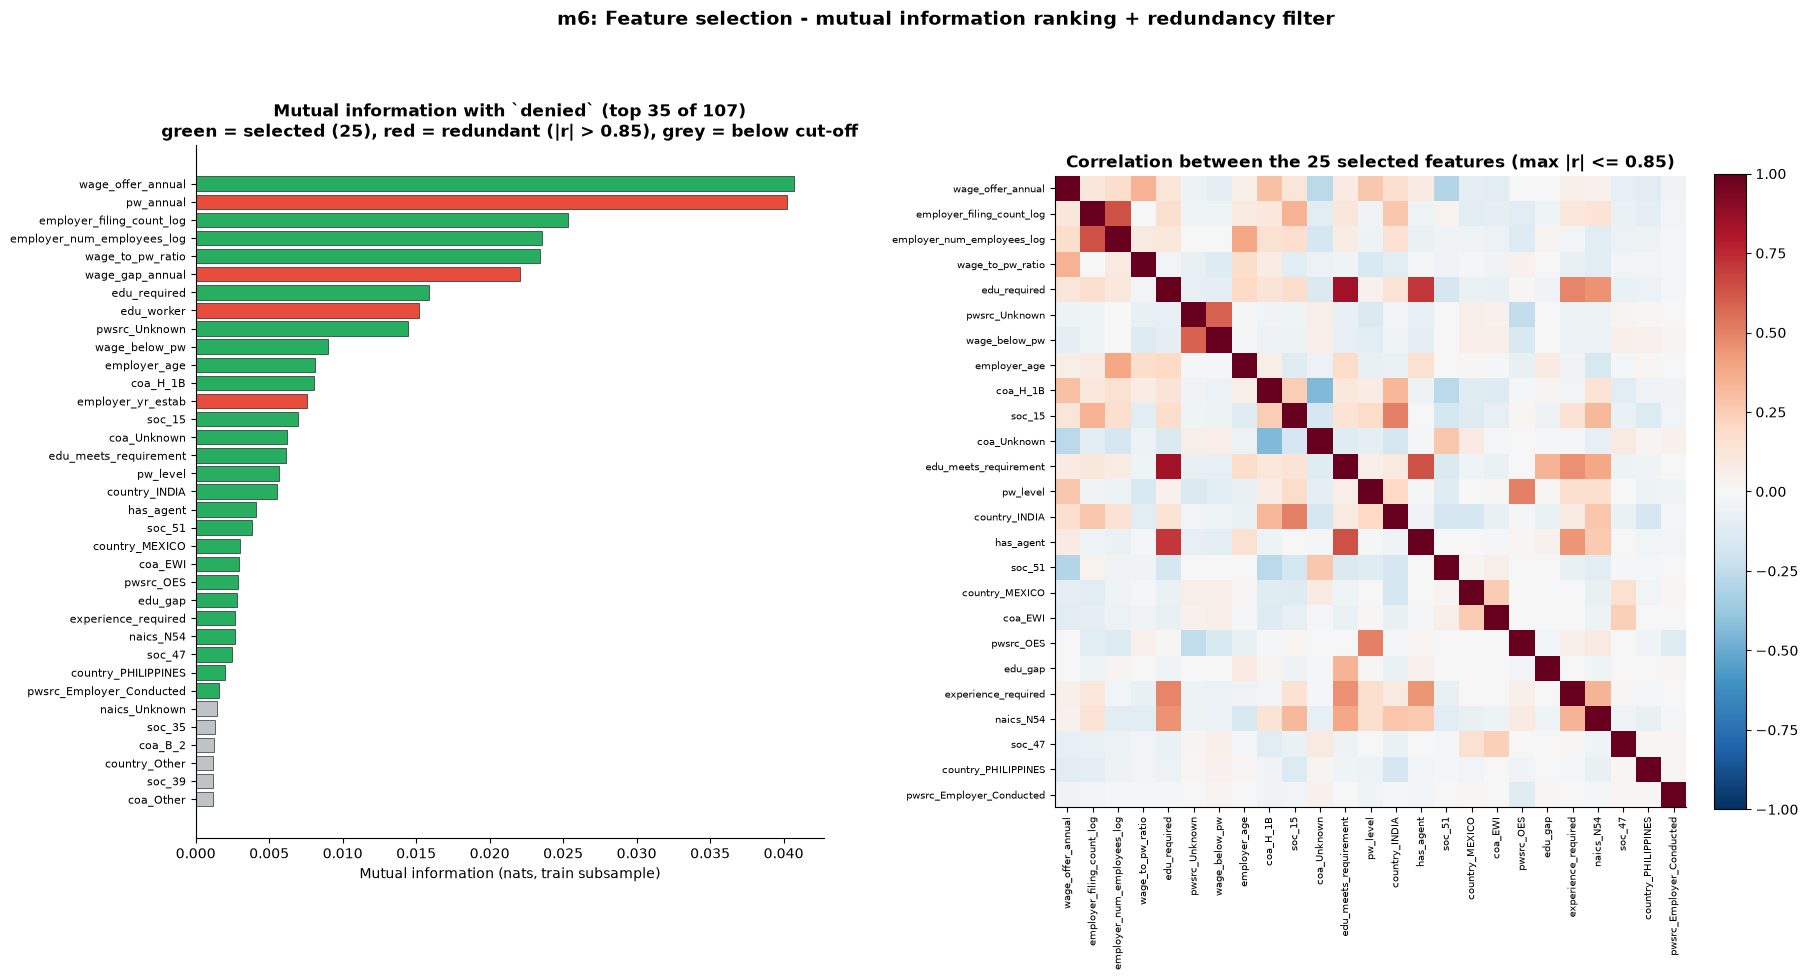

[Stage 6] 107 candidate features -> 5 redundant dropped -> 25 selected
Handover A (all features, unscaled): (354849, 109)
Handover B (selected, scaled):       (354849, 27)


,feature,mutual_information,rank,dropped_redundant_with,selected
0,wage_offer_annual,0.040705,1,NaN,True
1,pw_annual,0.040239,2,wage_offer_annual,False
2,employer_filing_count_log,0.025350,3,NaN,True
3,employer_num_employees_log,0.023553,4,NaN,True
4,wage_to_pw_ratio,0.023450,5,NaN,True
5,wage_gap_annual,0.022073,6,wage_to_pw_ratio,False
6,edu_required,0.015865,7,NaN,True
7,edu_worker,0.015191,8,edu_required,False
8,pwsrc_Unknown,0.014465,9,NaN,True
9,wage_below_pw,0.008986,10,NaN,True


In [3]:
# 1. Load Stage 5 (scaled) and Stage 4 (unscaled), select features, write both handover datasets (+ EDA plot m6)
df_5 = pd.read_parquet(os.path.join(OUT_DIR, 'stage5_scaled.parquet'))
df_4 = pd.read_parquet(os.path.join(OUT_DIR, 'stage4_features_created.parquet'))
print(f'Loaded Stage 5 data: {df_5.shape[0]:,} rows x {df_5.shape[1]} columns')
handover_a, handover_b, selection_report = stage6_feature_selection(df_5, df_4, show_plot=True)
print(f'Handover A (all features, unscaled): {handover_a.shape}')
print(f'Handover B (selected, scaled):       {handover_b.shape}')
selection_report.head(30)

In [4]:
# 2. Verification ("done when" checks)
for name in ['cleaned_unscaled_allfeatures.csv.gz', 'final_processed.csv.gz', 'selected_features.txt',
             'feature_dictionary.csv', 'feature_selection_report.csv']:
    assert os.path.exists(os.path.join(OUT_DIR, name)), f'missing output {name}'
b = pd.read_csv(os.path.join(OUT_DIR, 'final_processed.csv.gz'))
assert not set(LEAKAGE_COLS + EDA_ONLY_COLS) & set(b.columns)
assert set(b.columns) <= set(handover_a.columns)
selected = [c for c in b.columns if c not in (TARGET, 'split')]
assert b.loc[b['split'].eq('train'), selected].corr().abs().where(~np.eye(len(selected), dtype=bool)).max().max() <= CORR_THRESHOLD
print(f'Handover B reloaded: {b.shape} | denied {b[TARGET].mean():.2%} | splits {b["split"].value_counts().to_dict()}')
print('All Stage 6 checks passed.')

Handover B reloaded: (354849, 27) | denied 6.91% | splits {'train': 283879, 'test': 70970}
All Stage 6 checks passed.


## 3. EDA Interpretation & Findings

1. **Wages and employer profile dominate.** The highest-MI features are the offered wage, the employer's filing history (`employer_filing_count_log`), employer size and `wage_to_pw_ratio`, followed by required education and the missing prevailing-wage source (`pwsrc_Unknown`).
2. **Redundancy filter removed 5 features:** `pw_annual` (|r| > 0.85 with `wage_offer_annual`), `wage_gap_annual` (with `wage_to_pw_ratio`), `edu_worker` (with `edu_required`), `employer_yr_estab` (with `employer_age`, r = -1) and `pwsrc_Other` (with `pwsrc_OES`).
3. **25 features selected** (90% of the remaining MI): 8 continuous / ordinal, 7 engineered or binary flags and 10 informative one-hot categories (H-1B, computer occupations, India / Mexico / Philippines, ...). The heatmap confirms no remaining pair exceeds |r| = 0.85.
4. **Handover:** B (25 scaled features + `denied` + `split`) is the default dataset for all six models; A (107 unscaled features) is an optional preprocessing variety. `feature_dictionary.csv` documents every column. Teammates must train only on `split == 'train'` (5-fold stratified CV) and touch `split == 'test'` once.